In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd 
import matplotlib.pyplot as plt 
from chai_style import apply_style, new_fig, title, source, save, TERRACOTTA, SLATE, TAN, MUTED
from pathlib import Path 

apply_style() 

DATA_PULLED = "2026-08-17" 

saved → charts/01-rate-vs-level.png


PosixPath('charts/01-rate-vs-level.png')

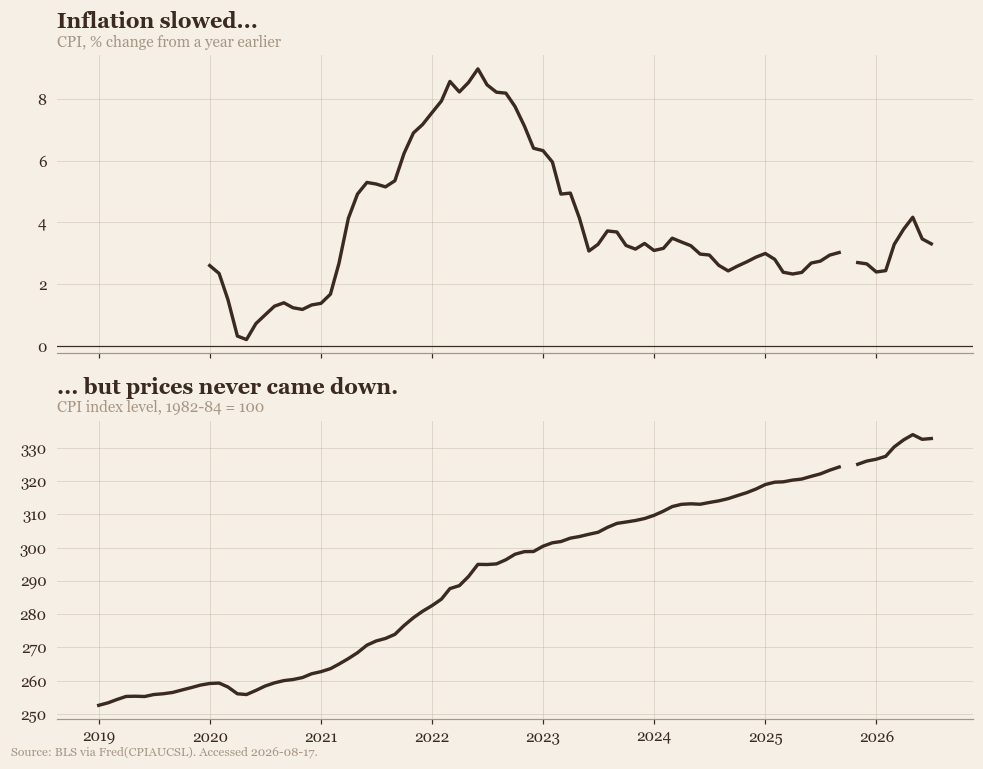

In [3]:
# Loading data 
df = pd.read_csv("data/cpi-all-items.csv", parse_dates=["observation_date"])
df = df.set_index("observation_date") 

# Calculate the rate from the level 
df["yoy"] = df["CPIAUCSL"].pct_change(12, fill_method=None) * 100

# Creating 2 panels with a shared x-axis 
fig, axs = new_fig(2, 1, figsize=(9, 7), sharex=True) 

# Top panel - the rate 
axs[0].plot(df.index, df["yoy"]) 
axs[0].axhline(0, linewidth=0.8) 
title(axs[0], "Inflation slowed...", "CPI, % change from a year earlier") 

# Bottom panel - the level 
axs[1].plot(df.index, df["CPIAUCSL"]) 
title(axs[1], "... but prices never came down.", "CPI index level, 1982-84 = 100") 

# Sources and final adjustments  
source(fig, f"Source: BLS via Fred(CPIAUCSL). Accessed {DATA_PULLED}. ")
fig.tight_layout() 
save(fig, "01-rate-vs-level")



Numbers to quote in the post (nothing in the prose that isn't here):
series  nominal_billions  price_index  volume_divide  volume_subtract
year                                                                 
2024                5.43         0.81           4.59             4.62
2025                1.37         2.42          -1.03            -1.06
saved → charts/03-jewelry-dollars-vs-volume.png


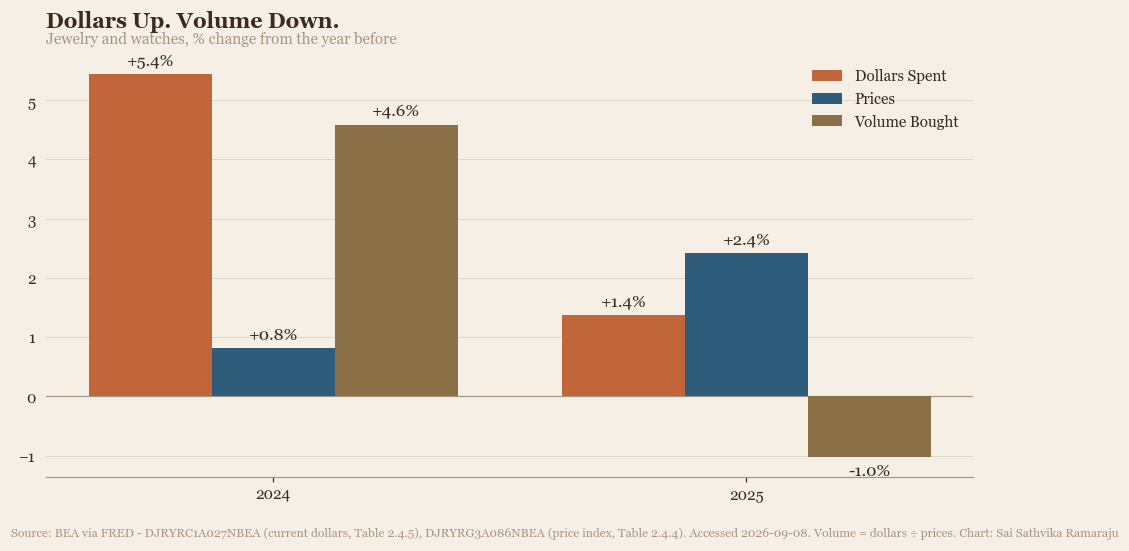

In [4]:
DATA_PULLED = "2026-09-08"
RAW = Path("data/jewelry.csv")

def load():
    df = pd.read_csv(RAW)
    return df.pivot(index="year", columns="series", values="value").sort_index()

def growth(wide): 
    g = wide.pct_change(fill_method=None) * 100 
    g["volume_divide"] = ((1 + g["nominal_billions"] / 100)
                          / (1 + g["price_index"] / 100) - 1) * 100 
    g["volume_subtract"] = g["nominal_billions"] - g["price_index"]
    return g.dropna() 

def build(g, outdir="charts"): 
    fig, ax = new_fig(figsize=(9, 5))
    
    x = range(len(g))
    w = 0.26 
    
    ax.bar([i - w for i in x], g["nominal_billions"], w, 
           color=TERRACOTTA, label="Dollars Spent")
    ax.bar([i     for i in x], g["price_index"], w, 
           color=SLATE, label="Prices")
    ax.bar([i + w for i in x], g["volume_divide"], w, 
           color=TAN, label="Volume Bought")
    
    ax.axhline(0, color=MUTED, linewidth=0.8, zorder=0)
    ax.set_xticks(list(x))
    ax.set_xticklabels([str(y) for y in g.index])
    ax.grid(False, axis="x")
    
    for i, row in enumerate(g.itertuples()):
        for val, off in ((row.nominal_billions, -w), 
                         (row.price_index, 0), 
                         (row.volume_divide, w)):
            ax.annotate(f"{val:+.1f}%", (i + off, val), ha="center", 
                        va="bottom" if val >= 0 else "top", 
                        xytext=(0, 4 if val >= 0 else -4), 
                        textcoords="offset points",
                        fontsize=11, fontfamily="serif")
            
    ax.legend(loc="upper right")
    
    title(ax, "Dollars Up. Volume Down.", 
          "Jewelry and watches, % change from the year before")
    source(fig, 'Source: BEA via FRED - DJRYRC1A027NBEA (current dollars, Table 2.4.5), '
           f"DJRYRG3A086NBEA (price index, Table 2.4.4). Accessed {DATA_PULLED}. "
           "Volume = dollars ÷ prices. Chart: Sai Sathvika Ramaraju")
    fig.tight_layout(rect=(0, 0.04, 1, 1))
    
    print("\nNumbers to quote in the post (nothing in the prose that isn't here):")
    print(g.round(2).to_string())
    save(fig, "03-jewelry-dollars-vs-volume", outdir=outdir)
    
build(growth(load()))


In [5]:
for row in open("data/pce-nominal-t24505.csv").readlines()[:6]:
    print(row[:80])

Table 2.4.5. Personal Consumption Expenditures by Type of Product

Table 2.4.5. Personal Consumption Expenditures by Type of Product

"Last Revised on: August 26, 2026 - Next Release Date September 30, 2026"

Line,,2024,2024,2024,2024,2025,2025,2025,2025,2026,2026

Line,,Q1,Q2,Q3,Q4,Q1,Q2,Q3,Q4,Q1,Q2

1,"            Personal consumption expenditures",19443.8,19756.1,20032.8,20351.


In [6]:
raw = pd.read_csv("data/pce-nominal-t24505.csv", header=[3,4])
print(list(raw.columns)[:5])

[('Line', 'Line'), ('Unnamed: 1_level_0', 'Unnamed: 1_level_1'), ('2024', 'Q1'), ('2024', 'Q2'), ('2024', 'Q3')]


In [7]:
def read_bea(path): 
    df = pd.read_csv(path, header=[3,4])
    df.columns = ["line_no", "line"] + [f"{year}{period}" for year, period in df.columns[2:]]
    
    long  = df.drop(columns="line_no").melt(
        id_vars="line", var_name="period", value_name="value"
    )
    long["line"] = long["line"].astype(str).str.strip()
    long["value"] = pd.to_numeric(
        long["value"].astype(str).str.replace(",", ""), errors="coerce"
    )
    long= long.dropna(subset=["value"])
    long["date"] = pd.PeriodIndex(
        long["period"].str.replace("Q", "-Q"), freq="Q"
    ).to_timestamp()
    return long 

nominal = read_bea("data/pce-nominal-t24505.csv")
real    = read_bea("data/pce-real-t24506.csv")
print(nominal.head())

                                line  period    value       date
0  Personal consumption expenditures  2024Q1  19443.8 2024-01-01
1                              Goods  2024Q1   6136.3 2024-01-01
2                      Durable goods  2024Q1   2126.3 2024-01-01
3           Motor vehicles and parts  2024Q1    712.8 2024-01-01
4            New motor vehicles (55)  2024Q1    381.2 2024-01-01


In [8]:
CATEGORIES = {
    "Groceries": "Food and beverages purchased for off-premises consumption", 
    "Household utilities": "Household utilities", 
    "Gasoline and energy goods": "Gasoline and other energy goods", 
}

for label, bea_line in CATEGORIES.items(): 
    print(label, "→", (nominal["line"] == bea_line).sum(), "rows")

Groceries → 10 rows
Household utilities → 10 rows
Gasoline and energy goods → 10 rows


In [9]:
def indexed(tidy, bea_line): 
    s = tidy[tidy["line"] == bea_line].set_index("date")["value"].sort_index()
    return s / s.iloc[0] * 100 

rows = [] 
for label, bea_line in CATEGORIES.items(): 
    d = indexed(nominal, bea_line)
    v = indexed(real, bea_line)
    rows.append({
        "category": label, 
        "dollars_%": d.iloc[-1] - 100, 
        "volume_%":  v.iloc[-1] - 100, 
        "gap_pp":    d.iloc[-1] - v.iloc[-1]
    })
    
summary = pd.DataFrame(rows).round(2)
print(summary.to_string(index=False))

                 category  dollars_%  volume_%  gap_pp
                Groceries       7.57      3.14    4.43
      Household utilities      14.86      3.01   11.85
Gasoline and energy goods      19.14      0.03   19.11


saved → charts/02-dollars-vs-volume.png


PosixPath('charts/02-dollars-vs-volume.png')

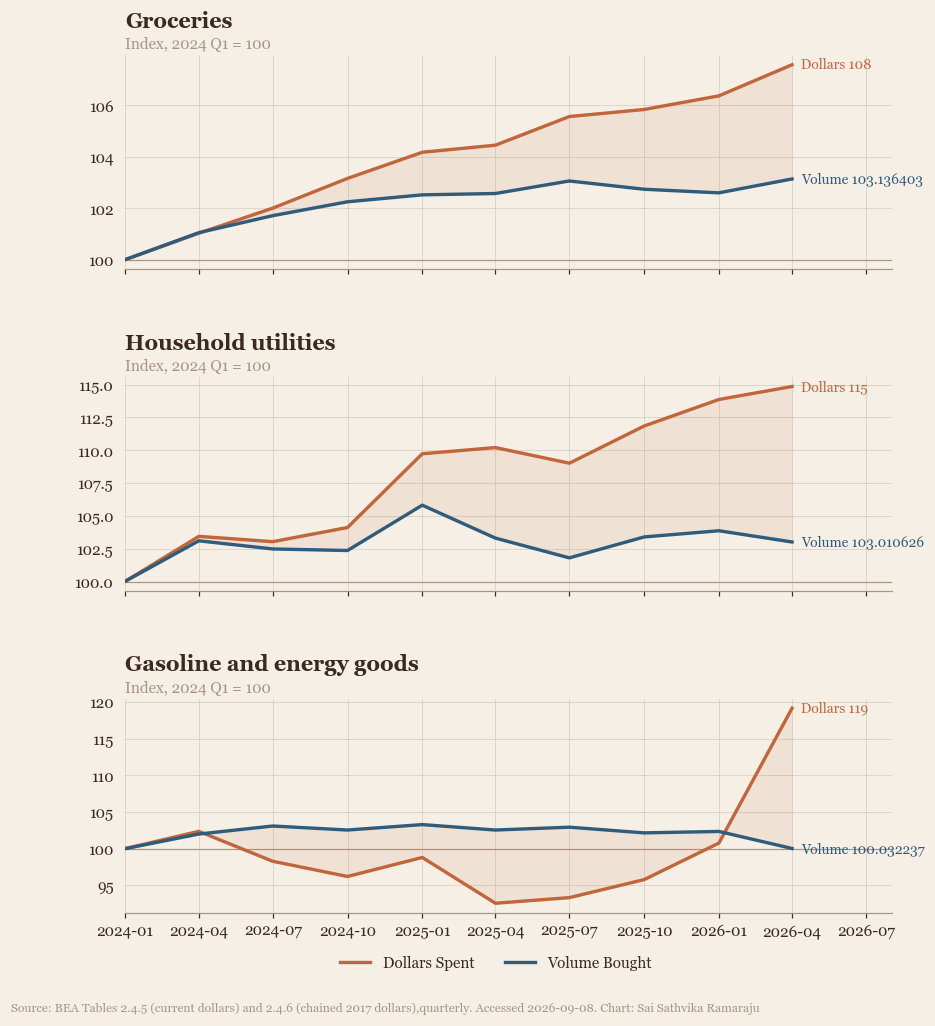

In [10]:
from chai_style import apply_style, new_fig, title, source, save, TERRACOTTA, SLATE, TAN, MUTED
fig, axs = new_fig(3, 1, figsize=(9, 10), sharex=True)

for ax, (label, bea_line) in zip(axs, CATEGORIES.items()):
    d = indexed(nominal, bea_line)
    v = indexed(real, bea_line)
    
    ax.fill_between(d.index, v, d, color=TERRACOTTA, alpha=0.10, linewidth=0)
    ax.plot(d.index, d, color=TERRACOTTA, label="Dollars Spent")
    ax.plot(v.index, v, color=SLATE, label="Volume Bought")
    ax.axhline(100, color=MUTED, linewidth=0.8, zorder=0)
    
    ax.annotate(f"Dollars {d.iloc[-1]:.0f}", (d.index[-1], d.iloc[-1]), 
                xytext=(6, 0), textcoords="offset points", 
                color=TERRACOTTA, fontsize=9, va="center", fontfamily="serif")
    ax.annotate(f"Volume {v.iloc[-1]:0f}", (v.index[-1], v.iloc[-1]), 
                xytext=(6, 0), textcoords="offset points", 
                color=SLATE, fontsize=9, va="center", fontfamily="serif")
    
    title(ax, label, "Index, 2024 Q1 = 100")
    span = d.index[-1] - d.index[0]
    ax.set_xlim(d.index[0], d.index[-1] + span * 0.15)

handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, 0.035), ncols=2)

source(fig, "Source: BEA Tables 2.4.5 (current dollars) and 2.4.6 (chained 2017 dollars),"
       f'quarterly. Accessed {DATA_PULLED}. Chart: Sai Sathvika Ramaraju')
fig.subplots_adjust(hspace=0.50, bottom=0.10)
save(fig, "02-dollars-vs-volume")